In [169]:
from sklearn.datasets import make_regression

# generating data
x, y = make_regression(n_samples=100, n_features=10, noise=1, random_state=42)

# Data analysis

1. plot target $`y`$ against feature $`x_5`$

Text(0, 0.5, 'y')

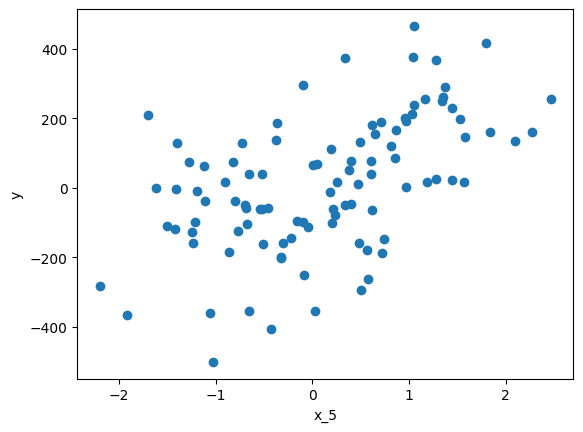

In [170]:
import matplotlib.pyplot as plt

plt.scatter(x[:, 5], y)
plt.xlabel("x_5")
plt.ylabel("y")

# Univariate regression

```math
\hat{y} = w*x+b
```
1. write a function `predict(w: float, x: float, b: float) -> float` that estimates target $`y`$ given feature $`x`$ and parameters $`w`$ and $`b`$ in the case of univariate linear regression
2. write a function `init_parameters() -> tuple[float, float]` that returns random values for parameters $`w`$ and $`b`$
3. apply the model for all the values of feature $`x_5`$ (compute $`\hat{y}`$)
4. add the regression line to the plot of target $`y`$ against feature $`x_5`$

In [171]:
b = -25.0
w = 100.0

def init_parameters() -> tuple[float, float]:
    """ write a function that initializes w and b to random values """
    ...
    return np.random.randn(), np.random.randn()

w, b = init_parameters()

def predict(w: float, x: float, b: float) -> float:
    """ write a function that predicts y given x, w and b in the case of univariate linear regression"""
    ...
    return w * x + b

Text(0, 0.5, 'y')

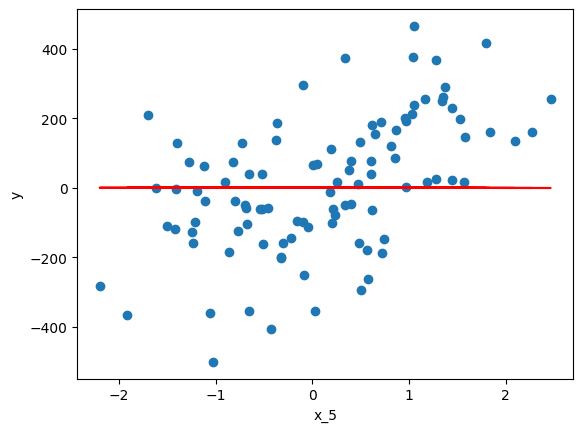

In [172]:
import matplotlib.pyplot as plt
import numpy as np

y_hat = predict(w, x[:, 5], b)

plt.scatter(x[:, 5], y)
plt.plot(x[:, 5], y_hat, color='red')
plt.xlabel("x_5")
plt.ylabel("y")

## Loss function: squared error

```math
L_{w,b}(x) = \frac{1}{2}(\hat{y}-y)^2 = \frac{1}{2}(w*x+b-y)^2
```

1. write a function ``loss_function(y: float, y_hat: float) -> float`` that computes the loss (squared error) between $`y`$ and $`\hat{y}`$

In [173]:
def loss_function(y: float, y_hat: float) -> float:
    """ write a function that computes the squared error between y and y_hat """
    ...
    return 1/2 * (y - y_hat) ** 2

In [174]:
loss_function(y, y_hat)

array([1.25449890e+05, 8.70056209e+04, 2.63680656e+04, 2.05505298e+04,
       1.69857321e+04, 8.15608754e+03, 1.73374737e+04, 2.09109186e+03,
       3.45555674e+02, 4.86942276e+03, 3.16165362e+04, 1.16382245e+03,
       6.69041440e+04, 1.97092347e+04, 2.99769510e+03, 1.09773902e+04,
       1.74292365e+04, 1.19192842e+04, 1.28954099e+04, 3.96340333e+04,
       7.32893558e+03, 6.99800909e+03, 5.15045180e+03, 6.34321005e+03,
       6.73550463e+04, 4.54344998e+03, 7.12288490e+04, 1.32539028e+04,
       1.62130880e+04, 1.08361469e+03, 7.63438180e+03, 3.28087814e+04,
       1.84258383e+03, 7.43103602e+01, 1.08544347e+05, 7.18885857e+00,
       5.03807584e+01, 7.53244099e+02, 1.75121559e+03, 3.28417280e+04,
       2.00112881e+03, 3.89694083e-02, 1.48338080e+02, 1.05452222e+04,
       6.96518634e+04, 1.30980457e+04, 1.61444024e+04, 6.28467458e+04,
       1.41318340e+02, 4.87896897e+03, 7.75746913e+02, 2.00432000e+04,
       1.08219837e+04, 6.50485081e+04, 7.60209053e+02, 1.85316993e+03,
      

## Cost function: mean squared error

```math
J_{w,b} = \frac{1}{2m}\sum{L_{w,b}(x)}
```

1. Write a function `cost_function(y: np.ndarray, y_hat: np.ndarray) -> float` that computes the cost (mean squared error) for a given set of parameters between $`y`$ and $`\hat{y}`$
2. plot the cost function for a large range of $`w`$ values

In [175]:
def cost_function(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ write a function that computes the mean squared error between y and y_hat """
    ...
    return sum(loss_function(y, y_hat)) / len(y)

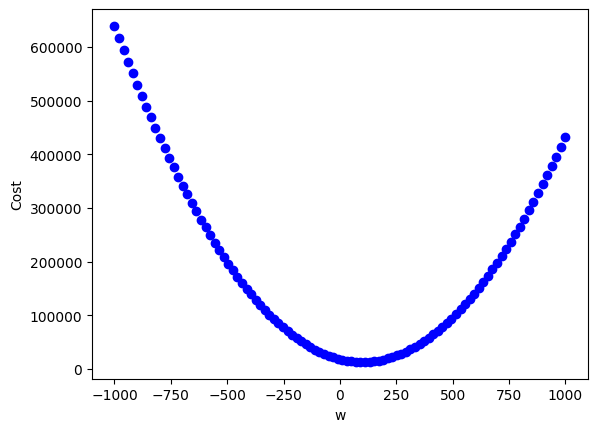

In [176]:
# plot loss function for different values of w
import matplotlib.pyplot as plt

w_range = np.linspace(-1000, 1000, 100)
for w in w_range:
    y_hat = predict(w, x[:, 5], b)
    cost = cost_function(y, y_hat)
    plt.scatter(w, cost, color='blue')
plt.xlabel("w")
plt.ylabel("Cost")
plt.show()

## Gradient Descent Step

```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{(\hat{y}-y)x}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```

1. write a function `compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[float, float]` that computes the gradient of the squared error loss with respect to parameters $`w`$ and $`b`$
2. write a function `update_parameters(w: float, b: float, dj_dw: float, dj_db: float, learning_rate: float) -> tuple[float, float]` that updates the parameters $`w`$ and $`b`$ using the gradients of the cost function $`\frac{\partial J}{\partial w}`$ and $`\frac{\partial J}{\partial b}`$ and the learning rate  $`\alpha`$
3. write a function `gradient_descent_one_step(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple[float, float]` that leverages methods, `predict`, `compute_gradient`, and `update_parameters`, that outputs updated parameters $`w`$ and $`b`$ for one step of gradient descent
4. write a function ``gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, n_iterations: int) -> tuple[float, float]`` that does $`n`$ iterations of gradient descent. Initialize values of parameters $`w`$ and $`b`$ randomly. Make sure to print/plot updated Cost per iteration (learning curve)
5. apply gradient descent for a sufficient $`n`$ iterations and plot the predicted values

Iteration 1/1000, Cost: 18220.731944517935
Iteration 26/1000, Cost: 17962.066637964846
Iteration 51/1000, Cost: 17716.73707121988
Iteration 76/1000, Cost: 17484.049557311508
Iteration 101/1000, Cost: 17263.346783186833
Iteration 126/1000, Cost: 17054.00588883936
Iteration 151/1000, Cost: 16855.436648506766
Iteration 176/1000, Cost: 16667.0797484857
Iteration 201/1000, Cost: 16488.405156403478
Iteration 226/1000, Cost: 16318.910577063518
Iteration 251/1000, Cost: 16158.119990243054
Iteration 276/1000, Cost: 16005.582266069825
Iteration 301/1000, Cost: 15860.86985383853
Iteration 326/1000, Cost: 15723.577540350161
Iteration 351/1000, Cost: 15593.321274066899
Iteration 376/1000, Cost: 15469.73705157413
Iteration 401/1000, Cost: 15352.479863028897
Iteration 426/1000, Cost: 15241.222693452157
Iteration 451/1000, Cost: 15135.655576890242
Iteration 476/1000, Cost: 15035.484700630379
Iteration 501/1000, Cost: 14940.431556805685
Iteration 526/1000, Cost: 14850.232138867508
Iteration 551/1000, C

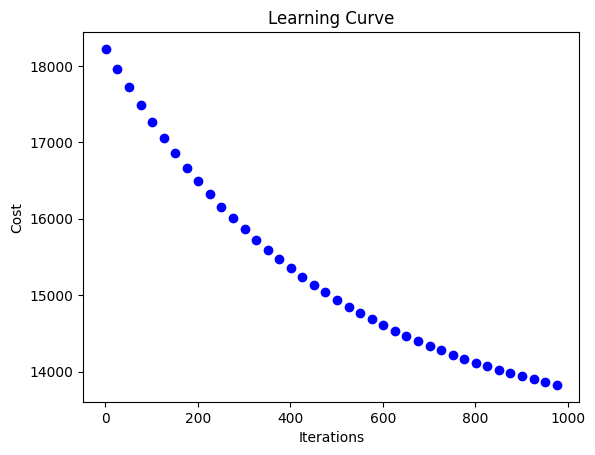

In [177]:
def compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[float, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    dw = ((y_hat - y) * x).mean()
    db = (y_hat - y).mean()
    return dw, db

def update_parameters(w: float, b: float, dj_dw: float, dj_db: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that updates the parameters w and b using the gradients dw and db and the learning rate """
    w = w - learning_rate * dj_dw
    b = b - learning_rate * dj_db
    return w, b

def gradient_descent_one_step(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that performs one step of gradient descent to optimize w and b """
    y_hat = predict(w, x, b)
    dw, db = compute_gradient(y, y_hat, x)
    w, b = update_parameters(w, b, dw, db, learning_rate)
    return w, b

def gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, n_iterations: int) -> tuple[float, float]:
    """ write a function that performs gradient descent to optimize w and b """
    w, b = init_parameters()

    # iterating gradient descent
    for i in range(n_iterations):
        
        # doing a single step of gradient descent
        w, b = gradient_descent_one_step(x, y, w, b, learning_rate)

        # computing cost for convergence check
        y_hat = predict(w, x, b)
        current_cost = cost_function(y, y_hat)
        
        # printing cost every 25 iterations
        if i % 25 == 0:
            print(f"Iteration {i+1}/{n_iterations}, Cost: {current_cost}")
            plt.scatter(i+1, current_cost, color='blue')

    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Learning Curve")
    plt.show()

    return w, b

w_hat, b_hat = gradient_descent(x[:, 5], y, learning_rate=0.001, n_iterations=1000)

Text(0, 0.5, 'y')

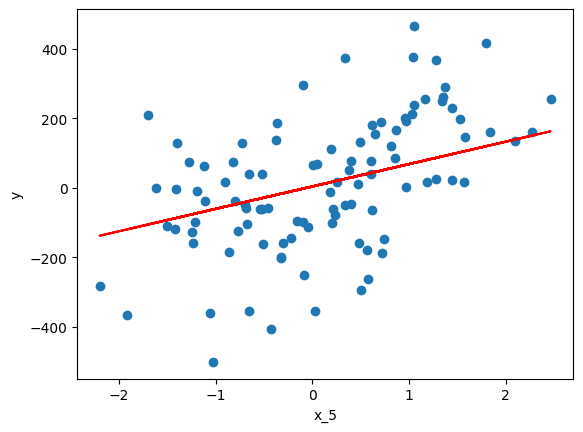

In [178]:

y_hat = predict(w_hat, x[:, 5], b_hat)

plt.scatter(x[:, 5], y)
plt.plot(x[:, 5], y_hat, color='red')
plt.xlabel("x_5")
plt.ylabel("y")

# Multivariate regression

```math
\hat{y} = w.x^T+b
```
1. write a function `predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray` that estimates target $`y`$ given features $`x`$ and parameters $`w`$ and $`b`$ in the case of multivariate linear regression
2. write a function `init_parameters(m: int) -> tuple[np.ndarray, float]` that returns random values for parameters $`w`$ and $`b`$, given the number of observations $`m`$
3. apply the model for all the features $`x`$ (compute $`\hat{y}`$)

In [185]:
def predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression"""
    return np.dot(w, x.T) + b


def init_parameters() -> tuple[np.ndarray, float]:
    """ write a function that initializes w and b to random values """
    ...
    return np.random.randn(x.shape[1]), np.random.randn()

w, b = init_parameters()

In [186]:
y_hat = predict(w, x, b)

In [187]:
cost_function(y, y_hat)

np.float64(18246.00180443933)

## Gradient Descent Step


```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{x^T.(\hat{y}-y)}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```
1. update the `compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, float]` for the multivariate linear regression

In [188]:
def compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    ...
    dw = np.dot(x.T, (y_hat - y)) / len(y)
    db = np.sum(y_hat - y) / len(y)
    return dw, db

compute_gradient(y, y_hat, x)

(array([ -30.22330151,  -55.50991702,   -6.75883446,  -71.09810467,
         -82.32774393, -102.35596431, -104.13991512,   35.98322411,
         -18.36313072,  -67.6546835 ]),
 np.float64(-10.61564541022573))

Iteration 1/1000, Cost: 14262.738034464408
Iteration 26/1000, Cost: 135.2591175531716
Iteration 51/1000, Cost: 7.766656211823561
Iteration 76/1000, Cost: 1.0785517528126176
Iteration 101/1000, Cost: 0.5194503100328186
Iteration 126/1000, Cost: 0.46832132851384456
Iteration 151/1000, Cost: 0.46355524366453965
Iteration 176/1000, Cost: 0.4631084817319614
Iteration 201/1000, Cost: 0.46306651647669733
Iteration 226/1000, Cost: 0.4630625711677618
Iteration 251/1000, Cost: 0.4630622001127438
Iteration 276/1000, Cost: 0.463062165209164
Iteration 301/1000, Cost: 0.46306216192567573
Iteration 326/1000, Cost: 0.46306216161677904
Iteration 351/1000, Cost: 0.463062161587718
Iteration 376/1000, Cost: 0.46306216158498514
Iteration 401/1000, Cost: 0.4630621615847285
Iteration 426/1000, Cost: 0.4630621615847021
Iteration 451/1000, Cost: 0.46306216158469893
Iteration 476/1000, Cost: 0.4630621615846978
Iteration 501/1000, Cost: 0.463062161584701
Iteration 526/1000, Cost: 0.4630621615846989
Iteration 551

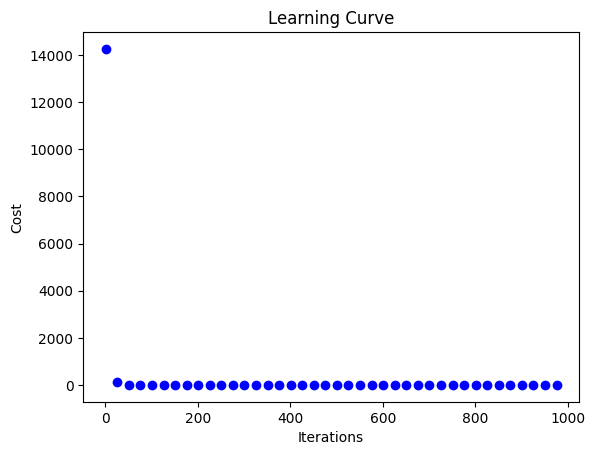

(array([16.91808294, 54.24713715,  5.06852656, 63.57562271, 93.58895955,
        70.57798635, 86.9399702 , 10.32117985,  3.2135643 , 70.89117187]),
 np.float64(0.13071043184342918))

In [189]:
gradient_descent(x, y, learning_rate=0.1, n_iterations=1000)

# Regularized Gradient Descent 
## Cost function

```math
J_{w,b} = \frac{1}{2m}\sum{L_{w,b}(x)} + \frac{\lambda_2}{2} \sum{w^2}
```

In [97]:
def predict(w: np.ndarray, x: np.ndarray, b: float, l: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression with L2 regularization"""
    return np.dot(w, x.T) + b

def gradient(y_true: np.ndarray, y_pred: np.ndarray, x: np.ndarray, w: np.ndarray, l: float) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b with L2 regularization """
    ...
    dw = (np.dot(x.T, (y_pred - y_true)) + l * w) / len(y_true)
    db = np.sum(y_pred - y_true) / len(y_true)
    return dw, db

